# Haptic Cart-Pole Bench Analysis

Load an HDF5 log from `haptic_bench.py` and analyze:
1. **Control loop timing** — loop period distribution, overruns
2. **Teensy→Mac latency** — measurement-to-receipt delay (requires clock sync)
3. **Motor command delay** — `f_command_mN` vs `force_sensed_mN` lag
4. **Pendulum state** — θ, θ̇ trajectories
5. **Force signals** — commanded, sensed, inferred human force

In [25]:
import h5py
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path

plt.rcParams.update({
    "figure.figsize": (14, 4),
    "axes.grid": True,
    "grid.alpha": 0.3,
})

# --- Load the most recent .h5 file (or set path manually) ---
h5_dir = Path(".")
h5_files = sorted(h5_dir.glob("haptic_bench_*.h5"), key=lambda p: p.stat().st_mtime)
if not h5_files:
    raise FileNotFoundError("No haptic_bench_*.h5 files found in current directory")
h5_path = h5_files[-1]
print(f"Loading: {h5_path}")

with h5py.File(h5_path, "r") as f:
    ds = f["samples"]
    data = ds[:]
    attrs = dict(ds.attrs)

print(f"Samples: {len(data)}")
print(f"Attributes: {attrs}")

# Convenience arrays
cycle       = data["cycle"]
t_meas_us   = data["t_meas_us"]
loop_us     = data["loop_us"]
x           = data["x"]
xdot        = data["xdot"]
xddot       = data["xddot"]
theta       = data["theta"]
thetadot    = data["thetadot"]
fx          = data["fx"]
fpc         = data["fpc"]
f_cmd_mN    = data["f_command_mN"]
f_sens_mN   = data["force_sensed_mN"]
arrival     = data["arrival_time"]

# Time axis from Teensy timestamps (seconds from first sample)
t_s = (t_meas_us - t_meas_us[0]) * 1e-6

Loading: haptic_bench_20260528_160956.h5
Samples: 33337
Attributes: {'clock_offset_us': 5539519837349.658, 'duration_s': 60.0, 'final_total_cycles': 33337, 'g': 9.81, 'l': 0.3, 'm_c': 2.0, 'm_p': 2.0, 'm_s': 4.0, 'max_force_mN': 50000.0, 'theta0': 0.1}


## 1. Control Loop Timing

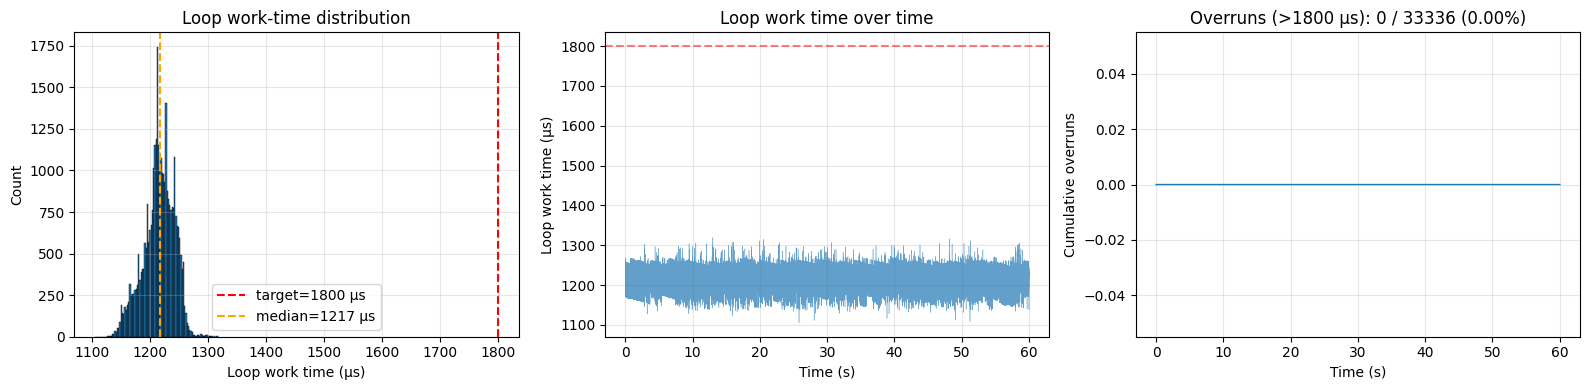

Metric            Value
------------------------
mean             1215.8 µs
median           1217.0 µs
std                26.4 µs
min              1105.0 µs
max              1319.0 µs
p95              1254.0 µs
p99              1265.0 µs


In [26]:
target_us = attrs.get("loop_period_us", 1800)

# NOTE: loop_us reports the *previous* iteration's work time (steps 1-11,
# including the UDP-command poll), and the first sample carries a sentinel 0.
# Align each duration to the cycle that actually produced it (the previous
# received sample) and drop the sentinel so it doesn't pollute the stats.
loop_dur = loop_us[1:].astype(np.float64)
t_dur    = t_s[:-1]
cyc_dur  = cycle[:-1]

fig, axes = plt.subplots(1, 3, figsize=(16, 4))

# Histogram
axes[0].hist(loop_dur, bins=100, edgecolor="black", linewidth=0.3)
axes[0].axvline(target_us, color="red", ls="--", label=f"target={target_us} µs")
axes[0].axvline(np.median(loop_dur), color="orange", ls="--",
                label=f"median={np.median(loop_dur):.0f} µs")
axes[0].set_xlabel("Loop work time (µs)")
axes[0].set_ylabel("Count")
axes[0].set_title("Loop work-time distribution")
axes[0].legend()

# Time series
axes[1].plot(t_dur, loop_dur, lw=0.3, alpha=0.7)
axes[1].axhline(target_us, color="red", ls="--", alpha=0.5)
axes[1].set_xlabel("Time (s)")
axes[1].set_ylabel("Loop work time (µs)")
axes[1].set_title("Loop work time over time")

# Overrun cumulative count
overrun_mask = loop_dur > target_us
overrun_cum = np.cumsum(overrun_mask)
axes[2].plot(t_dur, overrun_cum, lw=1)
axes[2].set_xlabel("Time (s)")
axes[2].set_ylabel("Cumulative overruns")
axes[2].set_title(f"Overruns (>{target_us} µs): {overrun_mask.sum()} / {len(loop_dur)} "
                  f"({100*overrun_mask.mean():.2f}%)")

plt.tight_layout()
plt.show()

# Stats table
print(f"{'Metric':<12} {'Value':>10}")
print("-" * 24)
for label, val in [
    ("mean",   np.mean(loop_dur)),
    ("median", np.median(loop_dur)),
    ("std",    np.std(loop_dur)),
    ("min",    np.min(loop_dur)),
    ("max",    np.max(loop_dur)),
    ("p95",    np.percentile(loop_dur, 95)),
    ("p99",    np.percentile(loop_dur, 99)),
]:
    print(f"{label:<12} {val:>10.1f} µs")

## 2. Teensy → Mac Latency

End-to-end delay from `t_meas_us` (Teensy `micros()` at acceleration read) to `arrival_time` (Mac `perf_counter` at socket receipt). Includes time spent in the telemetry batch buffer (~0–7 extra cycles) + Ethernet transit + Mac socket buffering.

Requires `clock_offset_us` from the clock sync performed before the run.

Because the Teensy batches up to 8 samples per UDP packet, the latency histogram looks like ~8 overlaid distributions: a sample's position within its batch (`cycle % 8`) sets how long it waited in the buffer before flush. The per-position mean/std breakdown follows.

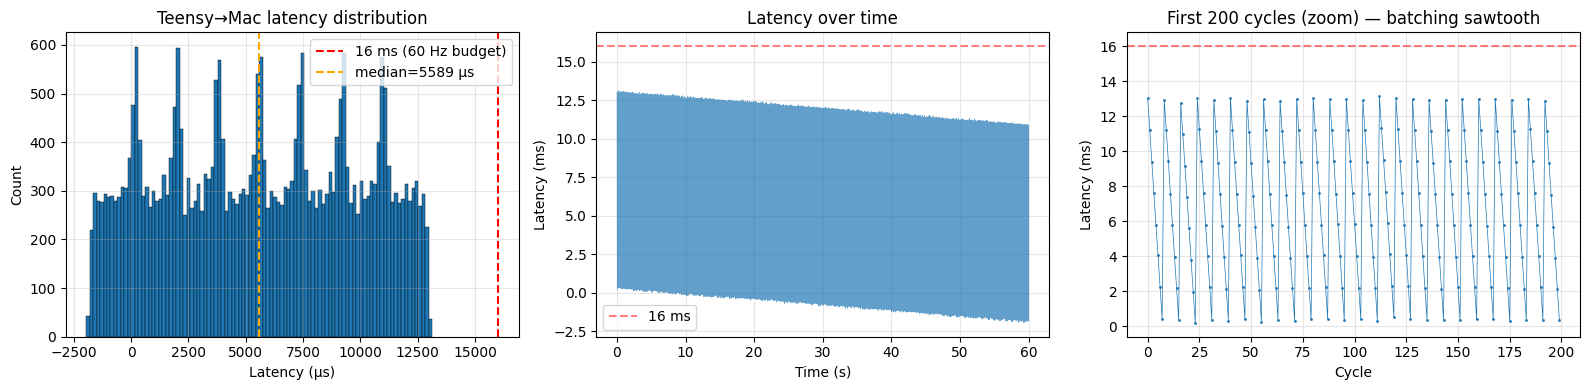

Samples >16 ms: 0 / 33337 (0.00%)
Latency stats (µs): mean=5596  median=5589  p95=12112  p99=12801  max=13136


In [27]:
clock_offset = attrs.get("clock_offset_us", None)

if clock_offset is None:
    print("No clock_offset_us in HDF5 attrs — skipping latency analysis.")
    print("Re-run haptic_bench.py (clock_sync runs automatically).")
else:
    # mac_perf_counter_us = teensy_us + clock_offset
    latency_us = arrival * 1e6 - (t_meas_us.astype(np.float64) + clock_offset)

    fig, axes = plt.subplots(1, 3, figsize=(16, 4))

    # Histogram
    axes[0].hist(latency_us, bins=100, edgecolor="black", linewidth=0.3)
    axes[0].axvline(16000, color="red", ls="--", label="16 ms (60 Hz budget)")
    axes[0].axvline(np.median(latency_us), color="orange", ls="--",
                    label=f"median={np.median(latency_us):.0f} µs")
    axes[0].set_xlabel("Latency (µs)")
    axes[0].set_ylabel("Count")
    axes[0].set_title("Teensy→Mac latency distribution")
    axes[0].legend()

    # Time series
    axes[1].plot(t_s, latency_us / 1000, lw=0.3, alpha=0.7)
    axes[1].axhline(16, color="red", ls="--", alpha=0.5, label="16 ms")
    axes[1].set_xlabel("Time (s)")
    axes[1].set_ylabel("Latency (ms)")
    axes[1].set_title("Latency over time")
    axes[1].legend()

    # Sawtooth pattern from batching: latency should rise within a batch
    # of 8 and drop when the batch is flushed. Show a zoomed window.
    zoom_n = min(200, len(latency_us))
    axes[2].plot(cycle[:zoom_n], latency_us[:zoom_n] / 1000, ".-", ms=2, lw=0.5)
    axes[2].axhline(16, color="red", ls="--", alpha=0.5)
    axes[2].set_xlabel("Cycle")
    axes[2].set_ylabel("Latency (ms)")
    axes[2].set_title(f"First {zoom_n} cycles (zoom) — batching sawtooth")

    plt.tight_layout()
    plt.show()

    over_16ms = np.sum(latency_us > 16000)
    print(f"Samples >16 ms: {over_16ms} / {len(latency_us)} "
          f"({100*over_16ms/len(latency_us):.2f}%)")
    print(f"Latency stats (µs): mean={latency_us.mean():.0f}  "
          f"median={np.median(latency_us):.0f}  "
          f"p95={np.percentile(latency_us, 95):.0f}  "
          f"p99={np.percentile(latency_us, 99):.0f}  "
          f"max={latency_us.max():.0f}")

### 2a. Latency by batch position

Each UDP packet carries up to `BATCH` samples (`MAX_SAMPLES_PER_PACKET` in the Teensy sketch). The first sample pushed into a batch waits ~`BATCH-1` cycles in the buffer before the flush; the last sample triggers the flush and waits ~0. The cycle counter starts at 0 and the buffer flushes every `BATCH` pushes, so a sample's batch position is exactly `cycle % BATCH`. Below: mean ± std latency for each position (expect a descending staircase), plus the per-position distributions that make up the combined histogram above.

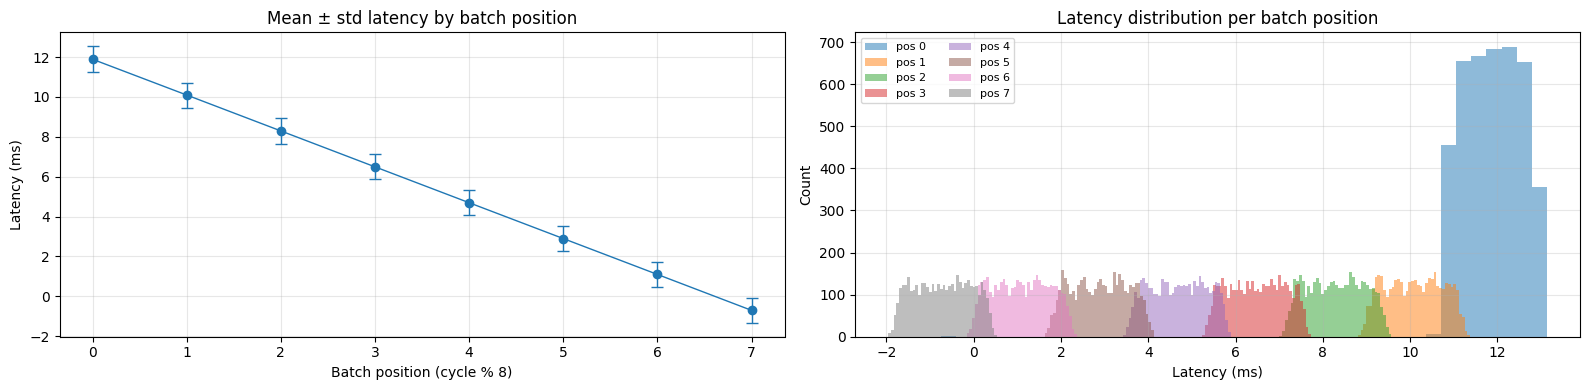

 pos    count      mean_us       std_us
--------------------------------------
   0     4168      11891.6        657.9
   1     4167      10097.4        627.9
   2     4167       8296.8        631.0
   3     4167       6494.8        629.1
   4     4167       4695.1        628.1
   5     4167       2896.9        628.0
   6     4167       1097.5        630.4
   7     4167       -704.9        628.7
--------------------------------------
 all    33337       5595.8       4171.9


In [28]:
if clock_offset is None:
    print("No clock_offset_us — skipping per-position latency breakdown.")
else:
    BATCH = 8  # MAX_SAMPLES_PER_PACKET in teensy_cartpole_haptic.ino
    batch_pos = (cycle % BATCH).astype(int)
    positions = np.arange(BATCH)

    means  = np.array([latency_us[batch_pos == p].mean() if np.any(batch_pos == p) else np.nan
                       for p in positions])
    stds   = np.array([latency_us[batch_pos == p].std()  if np.any(batch_pos == p) else np.nan
                       for p in positions])
    counts = np.array([int(np.sum(batch_pos == p)) for p in positions])

    fig, axes = plt.subplots(1, 2, figsize=(16, 4))

    # Mean ± std per position
    axes[0].errorbar(positions, means / 1000, yerr=stds / 1000,
                     fmt="o-", capsize=4, lw=1)
    axes[0].set_xlabel(f"Batch position (cycle % {BATCH})")
    axes[0].set_ylabel("Latency (ms)")
    axes[0].set_title("Mean ± std latency by batch position")
    axes[0].set_xticks(positions)

    # Per-position distributions
    for p in positions:
        sel = latency_us[batch_pos == p]
        if sel.size:
            axes[1].hist(sel / 1000, bins=40, alpha=0.5, label=f"pos {p}")
    axes[1].set_xlabel("Latency (ms)")
    axes[1].set_ylabel("Count")
    axes[1].set_title("Latency distribution per batch position")
    axes[1].legend(fontsize=8, ncol=2)

    plt.tight_layout()
    plt.show()

    # Stats table
    print(f"{'pos':>4} {'count':>8} {'mean_us':>12} {'std_us':>12}")
    print("-" * 38)
    for p in positions:
        print(f"{p:>4} {counts[p]:>8} {means[p]:>12.1f} {stds[p]:>12.1f}")
    print("-" * 38)
    print(f"{'all':>4} {len(latency_us):>8} {latency_us.mean():>12.1f} {latency_us.std():>12.1f}")

## 3. Motor Command Stream Delay

The motor's 0x64 response reports the force it is currently applying (`force_sensed_mN`), which lags the commanded force (`f_command_mN`) by approximately 3 frames. Cross-correlate to measure the actual lag.

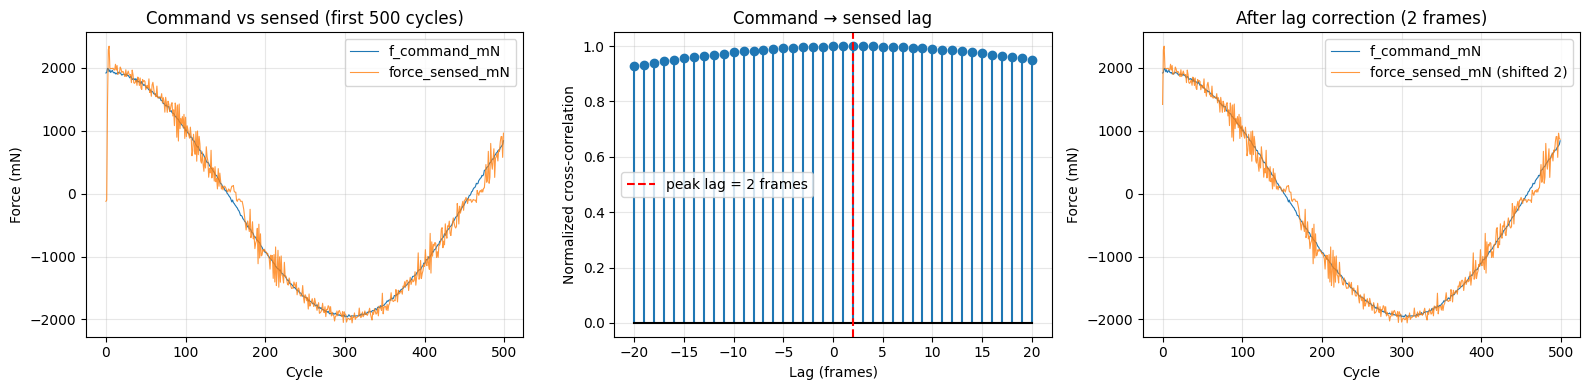

Estimated motor stream delay: 2 frames (≈ 3.6 ms)


In [29]:
fig, axes = plt.subplots(1, 3, figsize=(16, 4))

# Time series overlay (zoomed)
zoom_n = min(500, len(f_cmd_mN))
axes[0].plot(cycle[:zoom_n], f_cmd_mN[:zoom_n], label="f_command_mN", lw=0.8)
axes[0].plot(cycle[:zoom_n], f_sens_mN[:zoom_n], label="force_sensed_mN", lw=0.8, alpha=0.8)
axes[0].set_xlabel("Cycle")
axes[0].set_ylabel("Force (mN)")
axes[0].set_title(f"Command vs sensed (first {zoom_n} cycles)")
axes[0].legend()

# Cross-correlation to find lag
cmd_z = f_cmd_mN - f_cmd_mN.mean()
sens_z = f_sens_mN - f_sens_mN.mean()
max_lag = 20
lags = np.arange(-max_lag, max_lag + 1)
xcorr = np.array([
    np.correlate(cmd_z[:len(cmd_z)-abs(k)] if k >= 0 else cmd_z[-k:],
                 sens_z[k:] if k >= 0 else sens_z[:len(sens_z)+k])[0]
    for k in lags
])
# Normalize
norm = np.sqrt(np.sum(cmd_z**2) * np.sum(sens_z**2))
if norm > 0:
    xcorr /= norm

best_lag = lags[np.argmax(xcorr)]
# best_lag = 3

axes[1].stem(lags, xcorr, linefmt="C0-", markerfmt="C0o", basefmt="k-")
axes[1].axvline(best_lag, color="red", ls="--",
                label=f"peak lag = {best_lag} frames")
axes[1].set_xlabel("Lag (frames)")
axes[1].set_ylabel("Normalized cross-correlation")
axes[1].set_title("Command → sensed lag")
axes[1].legend()

# Overlay with lag correction
shift = max(best_lag, 0)
n_overlap = len(f_cmd_mN) - abs(best_lag)
axes[2].plot(cycle[:min(zoom_n, n_overlap)],
             f_cmd_mN[:min(zoom_n, n_overlap)],
             label="f_command_mN", lw=0.8)
axes[2].plot(cycle[:min(zoom_n, n_overlap)],
             f_sens_mN[shift:shift + min(zoom_n, n_overlap)],
             label=f"force_sensed_mN (shifted {best_lag})", lw=0.8, alpha=0.8)
axes[2].set_xlabel("Cycle")
axes[2].set_ylabel("Force (mN)")
axes[2].set_title(f"After lag correction ({best_lag} frames)")
axes[2].legend()

plt.tight_layout()
plt.show()

print(f"Estimated motor stream delay: {best_lag} frames "
      f"(≈ {best_lag * target_us / 1000:.1f} ms)")

## 4. Pendulum State Trajectories

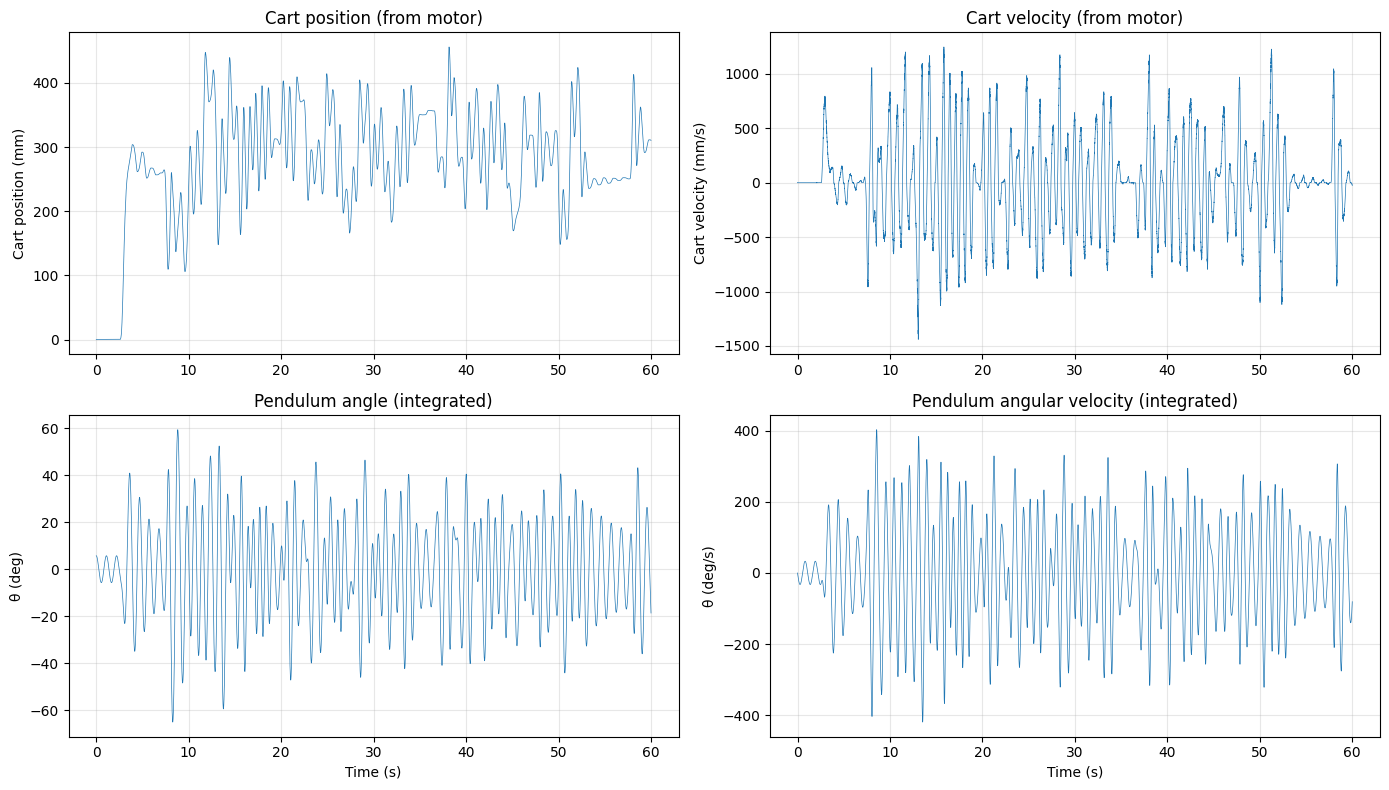

In [30]:
fig, axes = plt.subplots(2, 2, figsize=(14, 8))

# Cart position and velocity
axes[0, 0].plot(t_s, x * 1000, lw=0.5)
axes[0, 0].set_ylabel("Cart position (mm)")
axes[0, 0].set_title("Cart position (from motor)")

axes[0, 1].plot(t_s, xdot * 1000, lw=0.5)
axes[0, 1].set_ylabel("Cart velocity (mm/s)")
axes[0, 1].set_title("Cart velocity (from motor)")

# Pendulum angle and angular velocity
axes[1, 0].plot(t_s, np.degrees(theta), lw=0.5)
axes[1, 0].set_xlabel("Time (s)")
axes[1, 0].set_ylabel("θ (deg)")
axes[1, 0].set_title("Pendulum angle (integrated)")

axes[1, 1].plot(t_s, np.degrees(thetadot), lw=0.5)
axes[1, 1].set_xlabel("Time (s)")
axes[1, 1].set_ylabel("θ̇ (deg/s)")
axes[1, 1].set_title("Pendulum angular velocity (integrated)")

plt.tight_layout()
plt.show()

## 5. Force Signals

- `f_command_mN` — what the Teensy commanded the motor
- `force_sensed_mN` — what the motor reported back (lagged ~3 frames)
- `fpc` — pendulum reaction force on the cart (N)
- `fx` — inferred human force (N, diagnostic only)

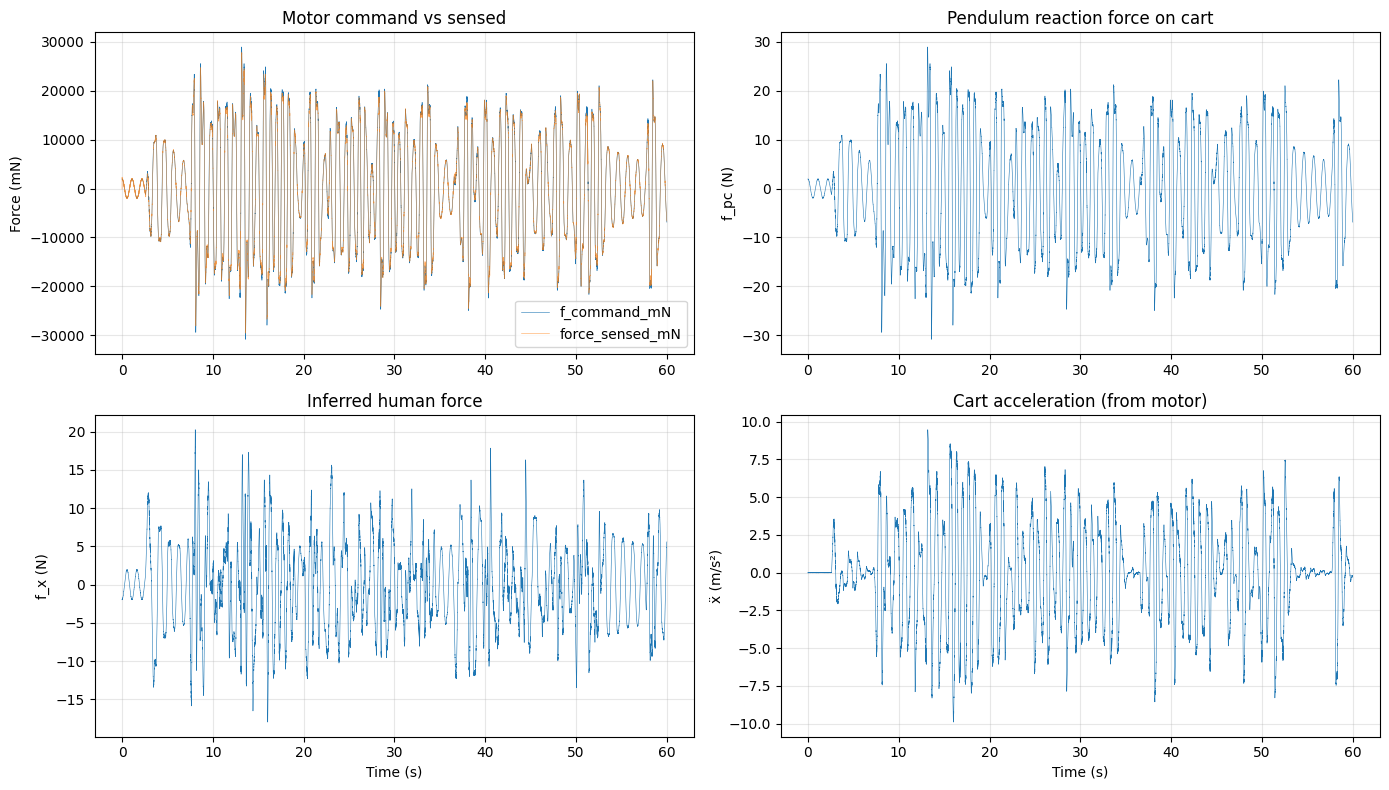

In [31]:
fig, axes = plt.subplots(2, 2, figsize=(14, 8))

axes[0, 0].plot(t_s, f_cmd_mN, lw=0.4, label="f_command_mN")
axes[0, 0].plot(t_s, f_sens_mN, lw=0.4, alpha=0.7, label="force_sensed_mN")
axes[0, 0].set_ylabel("Force (mN)")
axes[0, 0].set_title("Motor command vs sensed")
axes[0, 0].legend()

axes[0, 1].plot(t_s, fpc, lw=0.4)
axes[0, 1].set_ylabel("f_pc (N)")
axes[0, 1].set_title("Pendulum reaction force on cart")

axes[1, 0].plot(t_s, fx, lw=0.4)
axes[1, 0].set_xlabel("Time (s)")
axes[1, 0].set_ylabel("f_x (N)")
axes[1, 0].set_title("Inferred human force")

# Cart acceleration (drives the pendulum dynamics)
axes[1, 1].plot(t_s, xddot, lw=0.4)
axes[1, 1].set_xlabel("Time (s)")
axes[1, 1].set_ylabel("ẍ (m/s²)")
axes[1, 1].set_title("Cart acceleration (from motor)")

plt.tight_layout()
plt.show()

## 6. Packet Drop Analysis

Detect gaps in the cycle counter to find dropped UDP packets.

In [32]:
diffs = np.diff(cycle)
gaps = np.where(diffs != 1)[0]

expected = cycle[-1] - cycle[0] + 1
received = len(cycle)
dropped = expected - received

print(f"Total cycles: {expected}")
print(f"Received:     {received}")
print(f"Dropped:      {dropped} ({100*dropped/expected:.3f}%)")
print(f"Gap events:   {len(gaps)}")

if len(gaps) > 0 and len(gaps) <= 50:
    print(f"\nGap locations (cycle index → gap size):")
    for g in gaps:
        print(f"  cycle {cycle[g]} → {cycle[g+1]}: "
              f"gap of {diffs[g]} ({diffs[g]-1} missing)")
elif len(gaps) > 50:
    print(f"\nToo many gaps to list ({len(gaps)}). First 10:")
    for g in gaps[:10]:
        print(f"  cycle {cycle[g]} → {cycle[g+1]}: gap of {diffs[g]}")

if len(gaps) > 0:
    fig, ax = plt.subplots(figsize=(14, 3))
    ax.plot(cycle[:-1], diffs, ".", ms=0.5)
    ax.set_xlabel("Cycle")
    ax.set_ylabel("Δcycle")
    ax.set_title("Inter-cycle increments (should be 1 everywhere)")
    ax.set_ylim(0, min(diffs.max() + 1, 20))
    plt.tight_layout()
    plt.show()

Total cycles: 33337
Received:     33337
Dropped:      0 (0.000%)
Gap events:   0
